# Notebook 4 — EDA (the detailed one)

**Rule: work on the TRAIN split only. Do not open the test set here.**
Take your time on this notebook — everything after it depends on what you
find here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ARTIFACTS_DIR = "artifacts"
train = pd.read_parquet(f"{ARTIFACTS_DIR}/03_train.parquet")
print(train.shape)
train.head()

(67533, 25)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,n_unique_products,...,n_payment_installments,total_payment_value,n_payment_rows,main_payment_type,main_category,customer_state,customer_city,customer_zip_code_prefix,delivery_delay_days,is_late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,1.0,...,NaN,NaN,NaN,NaN,health_beauty,SP,sao joaquim da barra,14600,36.324745,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,1.0,...,1.0,45.46,1.0,boleto,watches_gifts,SP,sao paulo,4106,-0.415127,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,1.0,...,1.0,39.09,1.0,boleto,sports_leisure,RS,panambi,98280,-10.236366,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,1.0,1.0,...,1.0,35.61,1.0,credit_card,sports_leisure,RJ,rio de janeiro,22770,-16.542662,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,1.0,...,1.0,53.73,1.0,boleto,sports_leisure,RS,porto alegre,90040,-25.542975,0


## Data types, shape, memory

In [2]:
print(train.dtypes)
print()
print(train.info(memory_usage='deep'))

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
n_items                                 float64
n_unique_products                       float64
n_unique_sellers                        float64
total_price                             float64
total_freight                           float64
avg_item_price                          float64
max_shipping_limit_date                     str
n_payment_installments                  float64
total_payment_value                     float64
n_payment_rows                          float64
main_payment_type                           str
main_category                               str
customer_state                          

Classify columns manually so feature engineering (Notebook 5) is easy to plan:
- **numerical**: total_price, total_freight, avg_item_price, n_items, total_payment_value, n_payment_installments ...
- **categorical**: main_payment_type, main_category, customer_state, customer_city, order_status
- **date**: order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
- **id (drop for modeling)**: order_id, customer_id
- **label**: is_late

## Missing values — how many, where, and is the missingness itself meaningful?

In [3]:
missing = train.isna().mean().sort_values(ascending=False) * 100
print(missing[missing > 0])

main_category                   1.778390
order_approved_at               0.020731
order_delivered_carrier_date    0.001481
n_payment_installments          0.001481
n_payment_rows                  0.001481
total_payment_value             0.001481
main_payment_type               0.001481
dtype: float64


In [4]:
# is missingness related to the label? (e.g. missing review score for late orders?)
for col in missing[missing > 0].index[:8]:
    rate = train.groupby(train[col].isna())['is_late'].mean()
    print(f"{col:30s} late-rate when missing={rate.get(True, float('nan')):.3f}  "
          f"when present={rate.get(False, float('nan')):.3f}")

main_category                  late-rate when missing=0.095  when present=0.090
order_approved_at              late-rate when missing=0.000  when present=0.090
order_delivered_carrier_date   late-rate when missing=1.000  when present=0.090
n_payment_installments         late-rate when missing=1.000  when present=0.090
n_payment_rows                 late-rate when missing=1.000  when present=0.090
total_payment_value            late-rate when missing=1.000  when present=0.090
main_payment_type              late-rate when missing=1.000  when present=0.090


## Numerical columns: statistics, distributions, skew, outliers, weird ranges

In [5]:
num_cols = ['n_items', 'n_unique_products', 'n_unique_sellers', 'total_price',
            'total_freight', 'avg_item_price', 'n_payment_installments',
            'total_payment_value', 'n_payment_rows']
num_cols = [c for c in num_cols if c in train.columns]

display(train[num_cols].describe().T)
print("\nSkew:\n", train[num_cols].skew())

,count,mean,std,min,25%,50%,75%,max
n_items,67533.0,1.142079,0.541635,1.000000,1.00,1.00,1.000,21.00
n_unique_products,67533.0,1.037715,0.222223,1.000000,1.00,1.00,1.000,7.00
n_unique_sellers,67533.0,1.012053,0.114812,1.000000,1.00,1.00,1.000,5.00
total_price,67533.0,135.884499,205.187627,2.290000,45.90,85.00,149.900,13440.00
total_freight,67533.0,22.244256,19.999582,0.000000,14.10,16.79,23.700,1002.29
avg_item_price,67533.0,124.234649,185.653751,1.514286,41.00,78.97,139.900,6735.00
n_payment_installments,67532.0,2.974397,2.755007,1.000000,1.00,2.00,4.000,24.00
total_payment_value,67532.0,158.167657,214.277783,10.070000,61.63,104.19,175.485,13664.08
n_payment_rows,67532.0,1.047622,0.397212,1.000000,1.00,1.00,1.000,26.00



Skew:
 n_items                    8.106935
n_unique_products          7.675360
n_unique_sellers          10.525258
total_price               10.719309
total_freight              8.584291
avg_item_price             7.802797
n_payment_installments     1.592864
total_payment_value       10.149896
n_payment_rows            22.420165
dtype: float64


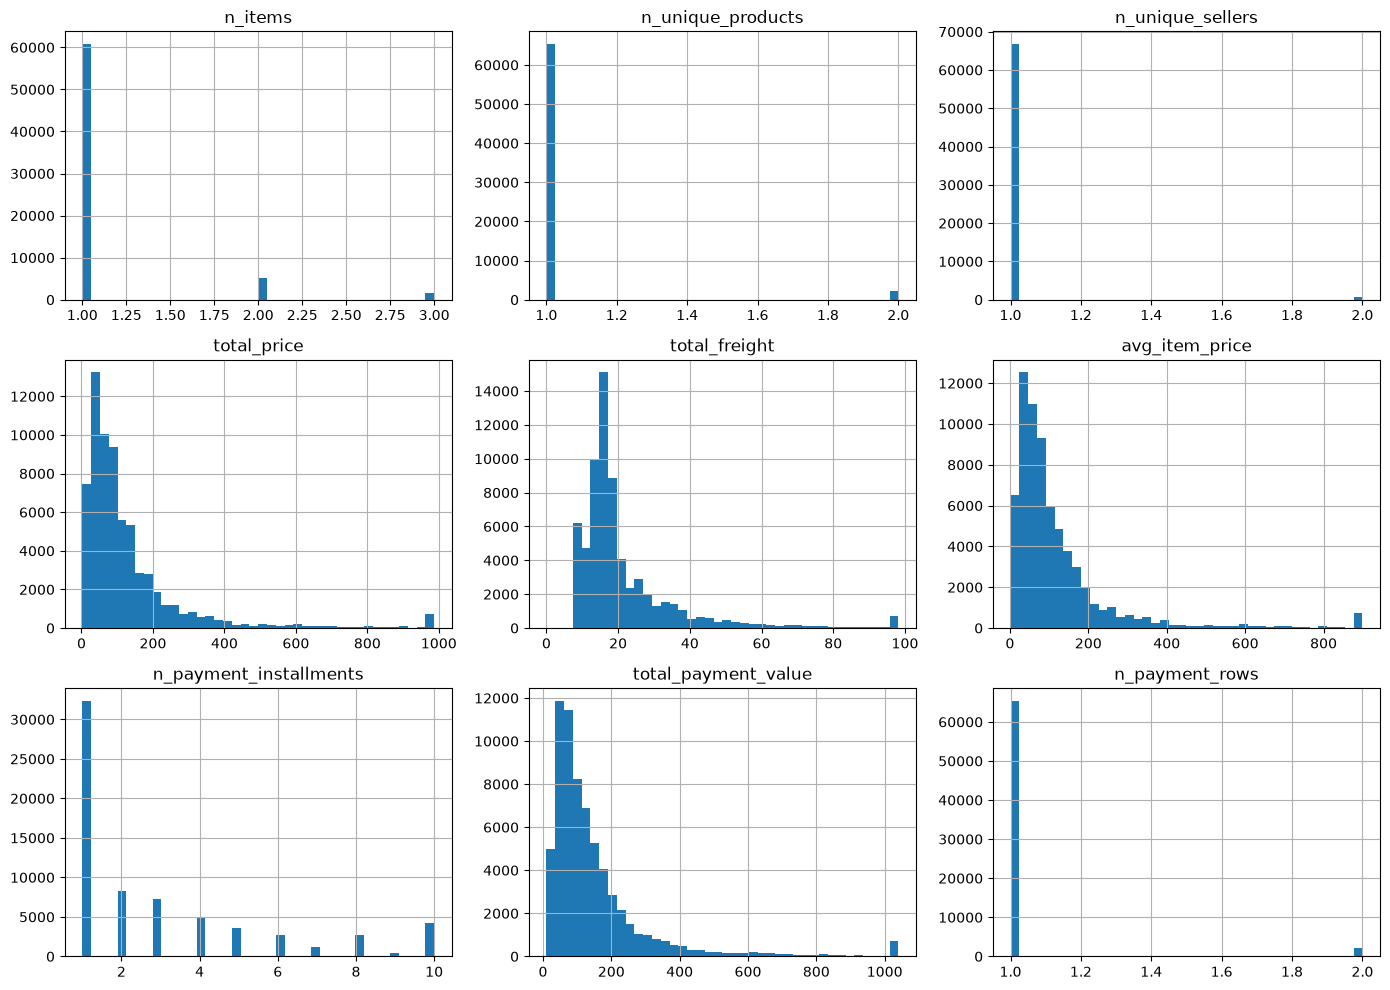

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, num_cols):
    train[col].clip(upper=train[col].quantile(0.99)).hist(ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/04_numeric_distributions.png", dpi=120)
plt.show()

In [7]:
# outlier / weird-range check with IQR
for col in num_cols:
    q1, q3 = train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((train[col] < lo) | (train[col] > hi)).sum()
    print(f"{col:25s} range=[{train[col].min():.1f}, {train[col].max():.1f}]  "
          f"n_outliers(IQR)={n_out} ({n_out/len(train)*100:.1f}%)")

n_items                   range=[1.0, 21.0]  n_outliers(IQR)=6759 (10.0%)
n_unique_products         range=[1.0, 7.0]  n_outliers(IQR)=2210 (3.3%)
n_unique_sellers          range=[1.0, 5.0]  n_outliers(IQR)=776 (1.1%)
total_price               range=[2.3, 13440.0]  n_outliers(IQR)=5361 (7.9%)
total_freight             range=[0.0, 1002.3]  n_outliers(IQR)=6629 (9.8%)
avg_item_price            range=[1.5, 6735.0]  n_outliers(IQR)=5109 (7.6%)
n_payment_installments    range=[1.0, 24.0]  n_outliers(IQR)=4677 (6.9%)
total_payment_value       range=[10.1, 13664.1]  n_outliers(IQR)=5308 (7.9%)
n_payment_rows            range=[1.0, 26.0]  n_outliers(IQR)=2129 (3.2%)


## Categorical columns: value counts, cardinality, rare/messy categories

In [8]:
cat_cols = ['main_payment_type', 'main_category', 'customer_state', 'order_status']
cat_cols = [c for c in cat_cols if c in train.columns]

for col in cat_cols:
    print(f"--- {col} --- cardinality={train[col].nunique()}")
    print(train[col].value_counts(dropna=False).head(10))
    print()

--- main_payment_type --- cardinality=4
main_payment_type
credit_card    50919
boleto         13901
voucher         2014
debit_card       698
NaN                1
Name: count, dtype: int64

--- main_category --- cardinality=71
main_category
bed_bath_table           6585
sports_leisure           5607
health_beauty            5372
computers_accessories    4770
furniture_decor          4545
housewares               3519
watches_gifts            3267
telephony                3068
toys                     2987
cool_stuff               2939
Name: count, dtype: int64

--- customer_state --- cardinality=27
customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64

--- order_status --- cardinality=2
order_status
delivered    67527
canceled         6
Name: count, dtype: int64



## Relations: groupby against the label, cross-tabs, charts

In [9]:
for col in cat_cols:
    rate = train.groupby(col)['is_late'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(f"--- late rate by {col} (top 10) ---")
    display(rate.head(10))

--- late rate by main_payment_type (top 10) ---


,mean,count
main_payment_type,,
debit_card,0.098854,698
boleto,0.094094,13901
credit_card,0.089475,50919
voucher,0.080933,2014


--- late rate by main_category (top 10) ---


,mean,count
main_category,,
home_comfort_2,0.210526,19
audio,0.161943,247
cine_photo,0.150000,20
construction_tools_lights,0.148148,54
construction_tools_construction,0.143382,272
furniture_mattress_and_upholstery,0.138889,36
fashion_underwear_beach,0.135922,103
christmas_supplies,0.123596,89
home_confort,0.120275,291


--- late rate by customer_state (top 10) ---


,mean,count
customer_state,,
AL,0.278523,298
MA,0.215328,548
CE,0.182489,948
RR,0.172414,29
SE,0.170732,246
PI,0.166667,348
RJ,0.165830,8967
BA,0.149978,2307
PA,0.133705,718


--- late rate by order_status (top 10) ---


,mean,count
order_status,,
canceled,0.166667,6
delivered,0.090275,67527


is_late                   1.000000
total_freight             0.046604
avg_item_price            0.027386
total_payment_value       0.024756
total_price               0.021315
n_payment_installments    0.017182
n_payment_rows           -0.005894
n_items                  -0.016146
n_unique_products        -0.021611
n_unique_sellers         -0.025872
Name: is_late, dtype: float64


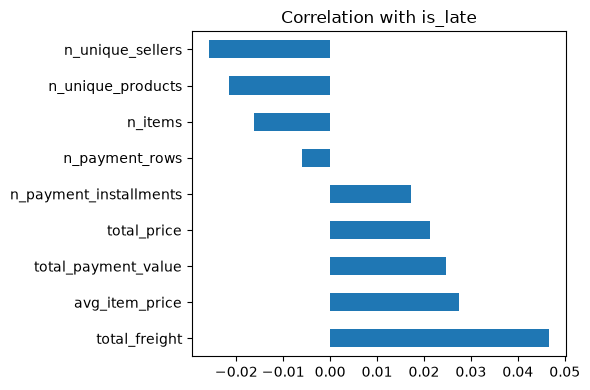

In [10]:
corr = train[num_cols + ['is_late']].corr()['is_late'].sort_values(ascending=False)
print(corr)

fig, ax = plt.subplots(figsize=(6, 4))
corr.drop('is_late').plot(kind='barh', ax=ax)
ax.set_title('Correlation with is_late')
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/04_correlation_with_label.png", dpi=120)
plt.show()

## Dates: order dates, delivery times, seasonality, weekday & holiday effects

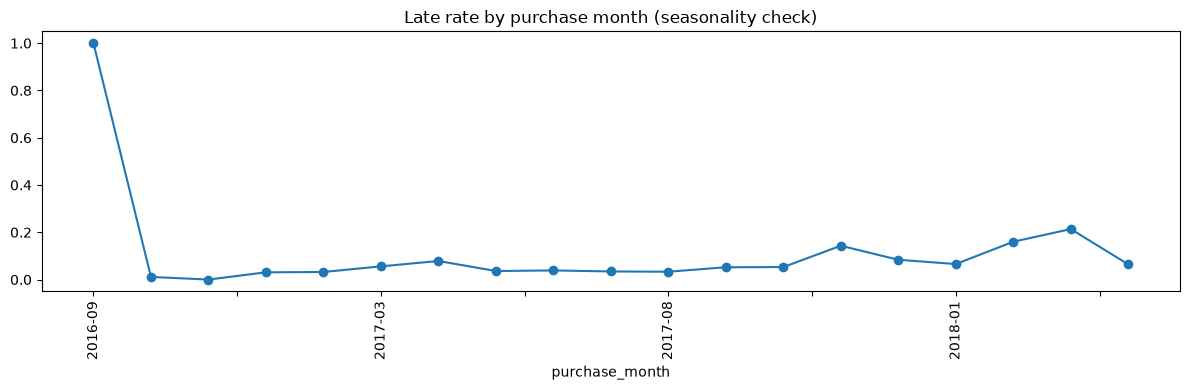

purchase_weekday
Monday       0.100224
Friday       0.094689
Tuesday      0.092646
Saturday     0.089676
Wednesday    0.086082
Sunday       0.083808
Thursday     0.082859
Name: is_late, dtype: float64


In [11]:
train['order_purchase_timestamp'] = pd.to_datetime(train['order_purchase_timestamp'])
train['purchase_month'] = train['order_purchase_timestamp'].dt.to_period('M').astype(str)
train['purchase_weekday'] = train['order_purchase_timestamp'].dt.day_name()
train['purchase_hour'] = train['order_purchase_timestamp'].dt.hour

monthly_late = train.groupby('purchase_month')['is_late'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
monthly_late.plot(kind='line', marker='o', ax=ax)
ax.set_title('Late rate by purchase month (seasonality check)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/04_seasonality.png", dpi=120)
plt.show()

print(train.groupby('purchase_weekday')['is_late'].mean().sort_values(ascending=False))

## Geography: customer state, distance proxy, ZIP-code prefix

,n,late_rate,avg_freight
customer_state,,,
AL,298,0.278523,37.513054
MA,548,0.215328,42.311442
CE,948,0.182489,35.290749
RR,29,0.172414,38.501379
SE,246,0.170732,40.332927
PI,348,0.166667,40.158707
RJ,8967,0.165830,23.349393
BA,2307,0.149978,28.960590
PA,718,0.133705,37.857214


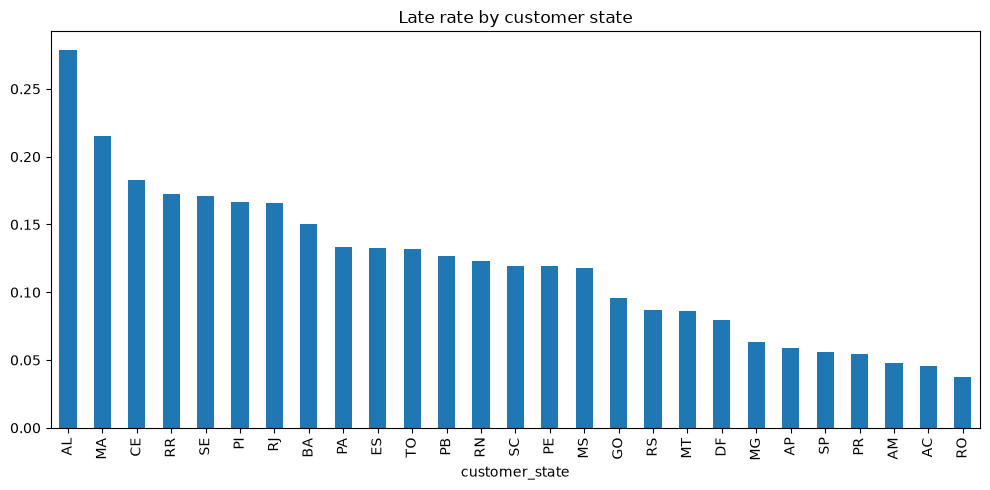

In [12]:
state_stats = train.groupby('customer_state').agg(
    n=('order_id', 'count'), late_rate=('is_late', 'mean'),
    avg_freight=('total_freight', 'mean')
).sort_values('late_rate', ascending=False)
display(state_stats)

fig, ax = plt.subplots(figsize=(10, 5))
state_stats['late_rate'].plot(kind='bar', ax=ax)
ax.set_title('Late rate by customer state')
plt.tight_layout()
plt.savefig(f"{ARTIFACTS_DIR}/04_late_rate_by_state.png", dpi=120)
plt.show()

## Findings summary — write this down for real before moving on

Fill this in based on what you actually saw above:

1. **Missing values**: which columns, and does missingness correlate with `is_late`?
2. **Outliers / weird ranges**: which numeric columns need capping or log-transform?
3. **Strongest categorical signal**: which category/state/payment type has the highest late-rate spread?
4. **Strongest numeric signal**: which column correlates most with `is_late`?
5. **Seasonality**: any months/weekdays with clearly higher late rates?
6. **Decision**: which features go into Notebook 5, and which raw columns get dropped
   (ids, near-constant columns, leaky columns like anything computed from
   `order_delivered_customer_date` itself)?

## Artifact: saved charts (above, in `artifacts/`) and this findings summary

In [13]:
with open(f"{ARTIFACTS_DIR}/04_findings_summary.md", "w", encoding="utf-8") as f:
    f.write("# EDA Findings Summary\n\n"
            "1. Missing values: ...\n"
            "2. Outliers: ...\n"
            "3. Strongest categorical signal: ...\n"
            "4. Strongest numeric signal: ...\n"
            "5. Seasonality: ...\n"
            "6. Feature decisions: ...\n")
print("Fill in artifacts/04_findings_summary.md with your real answers.")

Fill in artifacts/04_findings_summary.md with your real answers.
